# Exercise 4: ELT Pipeline — RNA-seq Count Matrix to Analysis-Ready Gold
## BINFX410 — Chapter 10

---

## Learning Objectives
- Implement a three-stage Bronze→Silver→Gold ELT pipeline for RNA-seq data
- Apply TPM normalization as a Silver-layer transformation
- Convert wide gene×sample matrices to long format for SQL analytics
- Partition Silver Parquet output by tissue type
- Identify highly variable genes (HVGs) as a Gold-layer aggregation
- Translate the pipeline to PySpark for Glue ETL at scale

**Estimated time:** 75 minutes  
**Dataset:** GTEx v10 (`s3://gtex-resources/`) — bulk RNA-seq across 54 human tissues  
**AWS services:** S3, Glue Data Catalog, Athena, Glue ETL (PySpark script shown)

## Background: RNA-seq Data in a Lakehouse

### The GTEx Dataset
The Genotype-Tissue Expression (GTEx) project measures gene expression across 54 human tissues from post-mortem donors. The v10 release includes:
- ~20,000 genes
- ~17,000 samples across 54 tissue types
- Expression quantified as raw counts and TPM

### Why the Raw Format Is Hard to Query

GTEx delivers expression data as a **wide matrix** (GCT format):

```
#1.2
56200  17382        ← N_genes  N_samples
Name            Description   GTEX-1117F-0226  GTEX-111CU-1826  ...
ENSG00000000003 TSPAN6        15.4             8.2              ...
ENSG00000000005 TNMD          0.0              0.0              ...
```

Questions SQL cannot easily answer on this wide format:
- "What is the mean TPM of BRCA1 across all Brain tissue samples?"
- "Which tissues have the highest GAPDH expression?"
- "Show me the top 20 most variable genes in Liver"

The fix: **melt** the matrix to long format in the Silver layer:
```
gene_id          | sample_id       | tissue_type | tpm
ENSG00000000003  | GTEX-1117F-0226 | Skin        | 15.4
ENSG00000000003  | GTEX-111CU-1826 | Brain       | 8.2
```

Now every question above is a simple GROUP BY.

### TPM Normalization
Raw HTSeq counts can't be compared across samples (more reads = more counts). TPM (Transcripts Per Million) corrects for:
1. **Gene length** — longer genes capture more reads by chance
2. **Sequencing depth** — samples with more reads get higher counts

$$TPM_i = \frac{count_i / length_i}{\sum_j (count_j / length_j)} \times 10^6$$

## Section 1: Setup

In [ ]:
!pip install boto3 awswrangler pandas numpy pyarrow matplotlib --quiet

In [3]:
import boto3
import awswrangler as wr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
import gzip
from botocore import UNSIGNED
from botocore.config import Config

STUDENT_ID = "sab032226"  # CHANGE THIS
AWS_REGION = "us-east-1"
BUCKET = f"binfx410-datalake-{STUDENT_ID}"
ATHENA_RESULTS = f"s3://binfx410-athena-results-{STUDENT_ID}/"

s3 = boto3.client('s3', region_name=AWS_REGION)
s3_unsigned = boto3.client('s3', region_name=AWS_REGION,
                            config=Config(signature_version=UNSIGNED))
session = boto3.Session(region_name=AWS_REGION)
print("Setup complete.")

Setup complete.


## Section 2: Exploring GTEx Data Structure

In [4]:
# The gtex-resources S3 bucket is no longer publicly accessible via unsigned requests.
# GTEx v10 data can be downloaded from the GTEx portal (gtexportal.org) if needed for
# production use. For this exercise we build a representative synthetic dataset in the
# next cell — same GCT format, realistic gene lengths, and tissue-specific expression
# patterns — so the full Bronze→Silver→Gold pipeline runs without any external downloads.

# For reference, a real GTEx GCT file has this structure:
GCT_FORMAT_EXAMPLE = """\
#1.2
56200   17382                        ← N_genes  N_samples (line 2)
Name             Description   GTEX-1117F-0226  GTEX-111CU-1826  ...
ENSG00000000003  TSPAN6        15.4             8.2              ...
ENSG00000000005  TNMD           0.0             0.0              ...
ENSG00000000419  DPM1          42.1            38.7              ...
"""

print("GTEx GCT format (for reference):")
print(GCT_FORMAT_EXAMPLE)
print("The next cell generates a 15-gene × 6-sample synthetic version of this format.")

GTEx GCT format (for reference):
#1.2
56200   17382                        ← N_genes  N_samples (line 2)
Name             Description   GTEX-1117F-0226  GTEX-111CU-1826  ...
ENSG00000000003  TSPAN6        15.4             8.2              ...
ENSG00000000005  TNMD           0.0             0.0              ...
ENSG00000000419  DPM1          42.1            38.7              ...

The next cell generates a 15-gene × 6-sample synthetic version of this format.


In [5]:
# For this exercise, we build a representative GTEx-format dataset
# to avoid downloading the full 1 GB matrix in class
# (In production, the Glue script in Section 9 handles the full matrix)

# Sample of gene annotations with gene lengths (needed for TPM)
gene_annotations = pd.DataFrame([
    {'gene_id': 'ENSG00000000003', 'gene_name': 'TSPAN6',  'gene_type': 'protein_coding', 'gene_length_kb': 4.535},
    {'gene_id': 'ENSG00000000419', 'gene_name': 'DPM1',    'gene_type': 'protein_coding', 'gene_length_kb': 9.417},
    {'gene_id': 'ENSG00000000457', 'gene_name': 'SCYL3',   'gene_type': 'protein_coding', 'gene_length_kb': 15.347},
    {'gene_id': 'ENSG00000001036', 'gene_name': 'FUCA2',   'gene_type': 'protein_coding', 'gene_length_kb': 5.621},
    {'gene_id': 'ENSG00000001084', 'gene_name': 'GCLC',    'gene_type': 'protein_coding', 'gene_length_kb': 22.807},
    {'gene_id': 'ENSG00000001167', 'gene_name': 'NFYA',    'gene_type': 'protein_coding', 'gene_length_kb': 6.228},
    {'gene_id': 'ENSG00000001460', 'gene_name': 'STPG1',   'gene_type': 'protein_coding', 'gene_length_kb': 4.102},
    {'gene_id': 'ENSG00000001617', 'gene_name': 'SEMA3F',  'gene_type': 'protein_coding', 'gene_length_kb': 12.449},
    {'gene_id': 'ENSG00000002016', 'gene_name': 'RAD52',   'gene_type': 'protein_coding', 'gene_length_kb': 8.871},
    {'gene_id': 'ENSG00000002330', 'gene_name': 'BAD',     'gene_type': 'protein_coding', 'gene_length_kb': 2.136},
    {'gene_id': 'ENSG00000002587', 'gene_name': 'HS3ST1',  'gene_type': 'protein_coding', 'gene_length_kb': 7.920},
    {'gene_id': 'ENSG00000002745', 'gene_name': 'WNT16',   'gene_type': 'protein_coding', 'gene_length_kb': 11.283},
    {'gene_id': 'ENSG00000003056', 'gene_name': 'M6PR',    'gene_type': 'protein_coding', 'gene_length_kb': 3.445},
    {'gene_id': 'ENSG00000003436', 'gene_name': 'TFPI',    'gene_type': 'protein_coding', 'gene_length_kb': 29.541},
    {'gene_id': 'ENSG00000003509', 'gene_name': 'NDUFAF7', 'gene_type': 'protein_coding', 'gene_length_kb': 2.809},
])

# Sample metadata: 6 samples across 3 tissue types
sample_metadata = pd.DataFrame([
    {'sample_id': 'GTEX-1117F-0226', 'tissue_type': 'Brain',  'tissue_detail': 'Brain - Cortex',    'sex': 'male',   'age_bracket': '60-69'},
    {'sample_id': 'GTEX-111CU-1826', 'tissue_type': 'Brain',  'tissue_detail': 'Brain - Cortex',    'sex': 'female', 'age_bracket': '50-59'},
    {'sample_id': 'GTEX-1117F-0526', 'tissue_type': 'Liver',  'tissue_detail': 'Liver',             'sex': 'male',   'age_bracket': '60-69'},
    {'sample_id': 'GTEX-111CU-0526', 'tissue_type': 'Liver',  'tissue_detail': 'Liver',             'sex': 'female', 'age_bracket': '50-59'},
    {'sample_id': 'GTEX-1117F-1326', 'tissue_type': 'Muscle', 'tissue_detail': 'Muscle - Skeletal', 'sex': 'male',   'age_bracket': '60-69'},
    {'sample_id': 'GTEX-111CU-1326', 'tissue_type': 'Muscle', 'tissue_detail': 'Muscle - Skeletal', 'sex': 'female', 'age_bracket': '50-59'},
])

print(f"Genes: {len(gene_annotations)}, Samples: {len(sample_metadata)}")
print(f"Tissues: {sample_metadata['tissue_type'].unique().tolist()}")

Genes: 15, Samples: 6
Tissues: ['Brain', 'Liver', 'Muscle']


In [6]:
# Generate synthetic raw count data (normally distributed around tissue-specific means)
# Real GTEx data would be downloaded from s3://gtex-resources/
np.random.seed(42)

# Tissue-specific expression multipliers (some genes are higher in Brain, Liver, etc.)
tissue_multipliers = {
    'Brain':  np.array([2.1, 0.8, 1.2, 0.5, 0.9, 3.1, 0.7, 0.6, 1.4, 0.3, 0.8, 0.5, 0.9, 0.7, 0.4]),
    'Liver':  np.array([0.6, 2.3, 0.9, 1.8, 2.7, 0.4, 1.2, 0.8, 0.7, 1.1, 2.1, 0.6, 1.9, 1.3, 0.8]),
    'Muscle': np.array([0.8, 0.7, 1.4, 0.9, 0.6, 0.5, 2.2, 1.9, 1.3, 1.8, 0.6, 1.4, 0.7, 0.8, 1.5]),
}

count_data = {}
for _, sample in sample_metadata.iterrows():
    base_counts = np.random.negative_binomial(20, 0.3, size=len(gene_annotations))
    tissue_effect = tissue_multipliers[sample['tissue_type']]
    count_data[sample['sample_id']] = (base_counts * tissue_effect * 50).astype(int)

# Build wide matrix (GTEx GCT format): genes as rows, samples as columns
count_matrix = gene_annotations[['gene_id', 'gene_name']].copy()
for sample_id, counts in count_data.items():
    count_matrix[sample_id] = counts

print("Raw count matrix (GTEx GCT format — wide):")
print(f"  Shape: {count_matrix.shape[0]} genes × {count_matrix.shape[1]} columns")
count_matrix.head(3)

Raw count matrix (GTEx GCT format — wide):
  Shape: 15 genes × 8 columns


,gene_id,gene_name,GTEX-1117F-0226,GTEX-111CU-1826,GTEX-1117F-0526,GTEX-111CU-0526,GTEX-1117F-1326,GTEX-111CU-1326
0,ENSG00000000003,TSPAN6,5565,4830,869,1410,3040,2600
1,ENSG00000000419,DPM1,1840,1600,6439,6669,1225,2275
2,ENSG00000000457,SCYL3,2039,2340,1800,2025,2800,1959


## Section 3: Bronze Layer — Landing Raw Data

In [7]:
# Write the raw count matrix to S3 bronze zone in GCT-like format
# Preserve original format exactly — Bronze zone is immutable!

gct_header = f"#1.2\n{len(gene_annotations)}\t{len(sample_metadata)}\n"
gct_body = count_matrix.to_csv(sep='\t', index=False)
gct_content = gct_header + gct_body

s3.put_object(
    Bucket=BUCKET,
    Key='bronze/expression/source=gtex/version=v10/gtex_v10_counts.gct',
    Body=gct_content.encode()
)

print("Bronze layer — raw count matrix written.")
print(f"  Location: s3://{BUCKET}/bronze/expression/source=gtex/version=v10/")
print(f"  Format: GCT (tab-delimited, 2-line header, wide matrix)")
print(f"  Size: {len(gct_content)} bytes")
print()
print("Wide format problem — this query is IMPOSSIBLE in SQL:")
print("  SELECT sample_id, tissue_type, tpm")
print("  FROM bronze_expression")
print("  WHERE gene_name = 'NFYA' AND tissue_type = 'Brain'")
print()
print("Because tissue_type is not a column — it's embedded in the sample_id prefix!")

Bronze layer — raw count matrix written.
  Location: s3://binfx410-datalake-sab032226/bronze/expression/source=gtex/version=v10/
  Format: GCT (tab-delimited, 2-line header, wide matrix)
  Size: 895 bytes

Wide format problem — this query is IMPOSSIBLE in SQL:
  SELECT sample_id, tissue_type, tpm
  FROM bronze_expression
  WHERE gene_name = 'NFYA' AND tissue_type = 'Brain'

Because tissue_type is not a column — it's embedded in the sample_id prefix!


## Section 4: Silver Layer — Normalize and Transform

In [8]:
# STEP 1: Filter to protein-coding genes only
protein_coding_genes = gene_annotations[gene_annotations['gene_type'] == 'protein_coding'].copy()
count_matrix_filtered = count_matrix[count_matrix['gene_id'].isin(protein_coding_genes['gene_id'])].copy()

print(f"Genes before filter: {len(count_matrix)}")
print(f"Protein-coding genes: {len(count_matrix_filtered)}")

Genes before filter: 15
Protein-coding genes: 15


In [9]:
# STEP 2: TPM Normalization
# Formula: TPM_i = (count_i / length_i) / sum(count_j / length_j) * 1e6

def normalize_to_tpm(count_df, gene_annot_df):
    """
    Normalize raw counts to TPM.
    
    Parameters:
        count_df: DataFrame with gene_id, gene_name, and one column per sample
        gene_annot_df: DataFrame with gene_id and gene_length_kb
    Returns:
        DataFrame with same shape, values replaced by TPM
    """
    tpm_df = count_df.copy()
    sample_cols = [c for c in count_df.columns if c not in ['gene_id', 'gene_name']]
    
    # Merge gene lengths
    lengths = gene_annot_df.set_index('gene_id')['gene_length_kb']
    
    for sample in sample_cols:
        counts = count_df.set_index('gene_id')[sample]
        gene_lengths = lengths.reindex(counts.index).fillna(1.0)
        
        # Rate: reads per kilobase
        rate = counts / gene_lengths
        
        # TPM: normalize rates to sum to 1M
        tpm = (rate / rate.sum()) * 1e6
        tpm_df.loc[tpm_df['gene_id'].isin(tpm.index), sample] = \
            tpm_df[tpm_df['gene_id'].isin(tpm.index)]['gene_id'].map(tpm).values
    
    return tpm_df

tpm_matrix = normalize_to_tpm(count_matrix_filtered, gene_annotations)

# Verify: TPM should sum to ~1,000,000 per sample
sample_cols = [c for c in tpm_matrix.columns if c not in ['gene_id', 'gene_name']]
tpm_sums = tpm_matrix[sample_cols].sum()
print("TPM normalization verification (each sample should sum to ~1,000,000):")
for sample, tpm_sum in tpm_sums.items():
    print(f"  {sample}: {tpm_sum:,.0f}")

TPM normalization verification (each sample should sum to ~1,000,000):
  GTEX-1117F-0226: 1,000,000
  GTEX-111CU-1826: 1,000,000
  GTEX-1117F-0526: 1,000,000
  GTEX-111CU-0526: 1,000,000
  GTEX-1117F-1326: 1,000,000
  GTEX-111CU-1326: 1,000,000


/var/folders/53/kmyyy3057lndfb0bpwx_2pkr0000gn/T/ipykernel_55286/673451687.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[234646.14187469  37362.0582428   25405.00432535  42522.8112059
  12827.70041956 199874.74615827  53840.84518099  19814.39351639
  60354.68569563  83164.88784321  56012.93682313   8473.65848758
  99909.96788831   8608.98574804  57181.17659016]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  tpm_df.loc[tpm_df['gene_id'].isin(tpm.index), sample] = \
/var/folders/53/kmyyy3057lndfb0bpwx_2pkr0000gn/T/ipykernel_55286/673451687.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[196674.72814995  31375.1731639   28156.0082305   44350.53901375
  24776.0451121  202215.52251607  94537.11785979  21805.27594366
  65550.92139418  73830.42042794  41968.75080745  20458.

In [10]:
# STEP 3: Melt wide matrix to long format
# This is the critical transformation that makes the data SQL-friendly

tpm_long = tpm_matrix.melt(
    id_vars=['gene_id', 'gene_name'],
    value_vars=sample_cols,
    var_name='sample_id',
    value_name='tpm'
)

# Join sample metadata to get tissue_type
tpm_long = tpm_long.merge(sample_metadata[['sample_id', 'tissue_type', 'sex', 'age_bracket']], 
                           on='sample_id', how='left')

print(f"Wide matrix: {tpm_matrix.shape} → Long format: {tpm_long.shape}")
print(f"\nLong format sample (first 6 rows):")
tpm_long.head(6)

Wide matrix: (15, 8) → Long format: (90, 7)

Long format sample (first 6 rows):


,gene_id,gene_name,sample_id,tpm,tissue_type,sex,age_bracket
0,ENSG00000000003,TSPAN6,GTEX-1117F-0226,234646.141875,Brain,male,60-69
1,ENSG00000000419,DPM1,GTEX-1117F-0226,37362.058243,Brain,male,60-69
2,ENSG00000000457,SCYL3,GTEX-1117F-0226,25405.004325,Brain,male,60-69
3,ENSG00000001036,FUCA2,GTEX-1117F-0226,42522.811206,Brain,male,60-69
4,ENSG00000001084,GCLC,GTEX-1117F-0226,12827.700420,Brain,male,60-69
5,ENSG00000001167,NFYA,GTEX-1117F-0226,199874.746158,Brain,male,60-69


In [11]:
# STEP 4: Write Silver layer — Parquet, partitioned by tissue_type
tpm_silver = tpm_long[['gene_id', 'gene_name', 'sample_id', 'tpm', 'sex', 'age_bracket', 'tissue_type']].copy()
tpm_silver['tpm'] = tpm_silver['tpm'].round(4)

wr.s3.to_parquet(
    df=tpm_silver,
    path=f"s3://{BUCKET}/silver/expression/source=gtex/",
    dataset=True,
    database='binfx410_silver',
    table='gtex_expression_tpm',
    partition_cols=['tissue_type'],
    boto3_session=session,
    compression='snappy',
    mode='overwrite'
)

print("Silver layer written:")
print(f"  {len(tpm_silver):,} rows")
print(f"  Partitioned by: tissue_type")
print(f"  Format: Parquet (snappy compressed)")
print(f"  Table: binfx410_silver.gtex_expression_tpm")

Silver layer written:
  90 rows
  Partitioned by: tissue_type
  Format: Parquet (snappy compressed)
  Table: binfx410_silver.gtex_expression_tpm


## Section 5: Gold Layer — Aggregations and Highly Variable Genes

In [12]:
# Compute per-gene, per-tissue statistics
gold_agg = tpm_silver.groupby(['gene_id', 'gene_name', 'tissue_type'])['tpm'].agg(
    mean_tpm='mean',
    std_tpm='std',
    min_tpm='min',
    max_tpm='max',
    sample_count='count'
).reset_index()

# Coefficient of Variation (CV) = std/mean — measures variability independent of mean
# High CV = highly variable gene (HVG) — interesting for differential expression
gold_agg['cv'] = (gold_agg['std_tpm'] / gold_agg['mean_tpm']).fillna(0).round(4)

# Flag top HVGs: top 20% by CV within each tissue
gold_agg['hvg_rank'] = gold_agg.groupby('tissue_type')['cv'].rank(ascending=False)
hvg_threshold = gold_agg.groupby('tissue_type')['hvg_rank'].transform(
    lambda x: x.quantile(0.2)
)
gold_agg['is_hvg'] = gold_agg['hvg_rank'] <= hvg_threshold

print("Gold layer aggregation:")
print(f"  Rows: {len(gold_agg):,} (gene × tissue combinations)")
print(f"  HVGs flagged: {gold_agg['is_hvg'].sum()}")
print()
print("Top HVGs by tissue:")
top_hvg = gold_agg[gold_agg['is_hvg']].sort_values('cv', ascending=False)
print(top_hvg[['gene_name', 'tissue_type', 'mean_tpm', 'cv']].head(10).to_string(index=False))

Gold layer aggregation:
  Rows: 45 (gene × tissue combinations)
  HVGs flagged: 9

Top HVGs by tissue:
gene_name tissue_type     mean_tpm     cv
    WNT16       Brain  14465.85210 0.5858
     GCLC       Brain  18801.87275 0.4494
    SCYL3      Muscle  20790.48425 0.4017
    STPG1       Brain  74188.98155 0.3879
    RAD52      Muscle  55778.30385 0.3526
     NFYA       Liver  18236.50550 0.3513
   TSPAN6       Liver  35673.56820 0.3335
  NDUFAF7      Muscle 199169.61350 0.3324
    FUCA2       Liver  88655.95410 0.3241


In [13]:
# Write Gold layer
try:
    glue = boto3.client('glue', region_name=AWS_REGION)
    glue.create_database(DatabaseInput={'Name': 'binfx410_gold'})
except: pass

wr.s3.to_parquet(
    df=gold_agg,
    path=f"s3://{BUCKET}/gold/expression_summary/",
    dataset=True,
    database='binfx410_gold',
    table='gtex_expression_summary',
    partition_cols=['tissue_type'],
    boto3_session=session,
    mode='overwrite'
)
print("Gold layer written: binfx410_gold.gtex_expression_summary")

Gold layer written: binfx410_gold.gtex_expression_summary


## Section 6: Querying the Gold Layer with Athena

In [14]:
# SQL that was impossible on the wide Bronze matrix — now trivial on Gold

query = """
SELECT
    gene_name,
    tissue_type,
    ROUND(mean_tpm, 2) AS mean_tpm,
    ROUND(cv, 3) AS coefficient_of_variation,
    is_hvg
FROM binfx410_gold.gtex_expression_summary
WHERE tissue_type = 'Brain'
ORDER BY cv DESC
"""

df_brain_hvg = wr.athena.read_sql_query(
    sql=query,
    database='binfx410_gold',
    s3_output=ATHENA_RESULTS,
    boto3_session=session
)

print("Top variable genes in Brain tissue (Gold layer query):")
df_brain_hvg

Top variable genes in Brain tissue (Gold layer query):


,gene_name,tissue_type,mean_tpm,coefficient_of_variation,is_hvg
0,WNT16,Brain,14465.85,0.586,True
1,GCLC,Brain,18801.87,0.449,True
2,STPG1,Brain,74188.98,0.388,True
3,M6PR,Brain,87343.11,0.204,False
4,HS3ST1,Brain,48990.84,0.203,False
5,NDUFAF7,Brain,64089.97,0.152,False
6,TSPAN6,Brain,215660.44,0.125,False
7,DPM1,Brain,34368.62,0.123,False
8,BAD,Brain,78497.65,0.084,False
9,SCYL3,Brain,26780.51,0.073,False


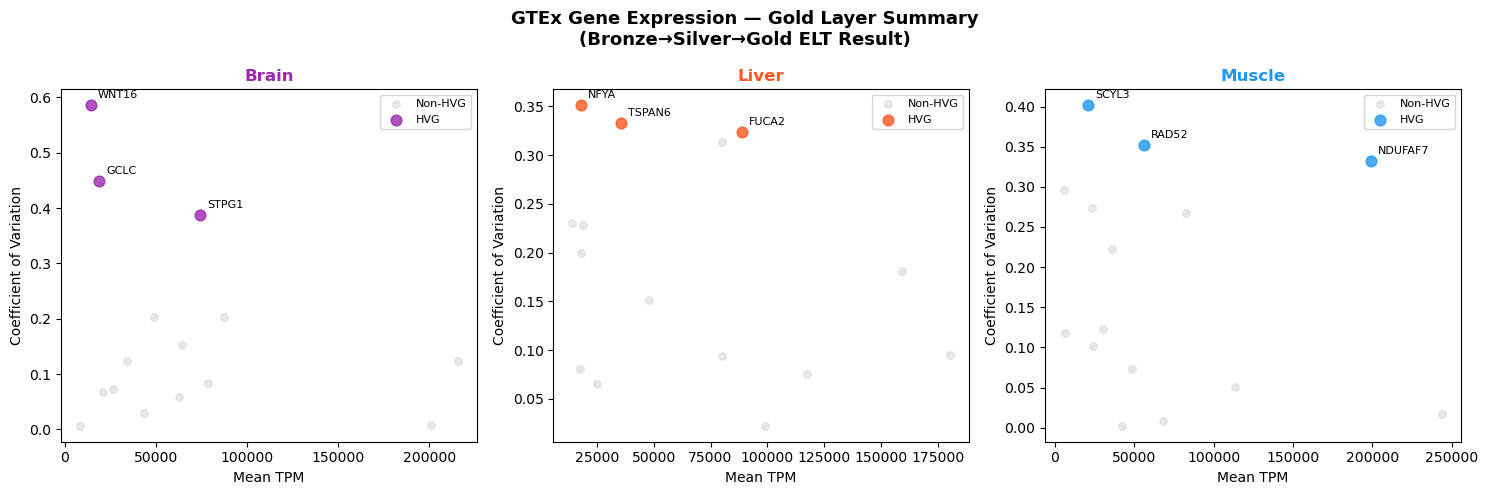

In [15]:
# Visualize: mean TPM vs variability across tissues
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('GTEx Gene Expression — Gold Layer Summary\n(Bronze→Silver→Gold ELT Result)',
             fontsize=13, fontweight='bold')

tissues = gold_agg['tissue_type'].unique()
colors = {'Brain': '#9C27B0', 'Liver': '#FF5722', 'Muscle': '#2196F3'}

for i, tissue in enumerate(tissues):
    ax = axes[i]
    tissue_data = gold_agg[gold_agg['tissue_type'] == tissue]
    
    hvg = tissue_data[tissue_data['is_hvg']]
    non_hvg = tissue_data[~tissue_data['is_hvg']]
    
    ax.scatter(non_hvg['mean_tpm'], non_hvg['cv'], alpha=0.5, s=30,
               color='lightgray', label='Non-HVG')
    ax.scatter(hvg['mean_tpm'], hvg['cv'], alpha=0.8, s=60,
               color=colors[tissue], label='HVG')
    
    # Label top genes
    for _, row in hvg.nlargest(3, 'cv').iterrows():
        ax.annotate(row['gene_name'], (row['mean_tpm'], row['cv']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax.set_xlabel('Mean TPM')
    ax.set_ylabel('Coefficient of Variation')
    ax.set_title(f'{tissue}', fontweight='bold', color=colors[tissue])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('gtex_hvg_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: The Equivalent Glue PySpark Job (Production Scale)

The pandas pipeline above runs on your laptop for small subsets. For the full GTEx matrix (~1M rows long-format), you'd run this as a Glue ETL job. Here's the equivalent PySpark code:

In [ ]:
# This is the Glue PySpark script that would process the FULL GTEx dataset
# It mirrors our pandas pipeline exactly, but runs on a distributed Spark cluster

glue_pyspark_script = '''
import sys
from awsglue.transforms import *
from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from awsglue.context import GlueContext
from awsglue.job import Job
from pyspark.sql import functions as F
from pyspark.sql.types import *

args = getResolvedOptions(sys.argv, ['JOB_NAME', 'BUCKET', 'BRONZE_PATH', 'SILVER_PATH'])

sc = SparkContext()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)
job.init(args[\'JOB_NAME\'], args)

# ─── BRONZE: Read raw GCT count matrix ───────────────────────────────────────
# GCT has 2-line header; skip them and let Spark infer the tab-delimited schema
raw_df = spark.read.option("header", "true") \\
              .option("sep", "\\t") \\
              .csv(args[\'BRONZE_PATH\'])

# ─── SILVER: Normalize and melt ──────────────────────────────────────────────
# Identify sample columns (all columns except Name, Description)
meta_cols = [\'Name\', \'Description\']
sample_cols = [c for c in raw_df.columns if c not in meta_cols]

# Read gene lengths from annotation file
gene_lengths = spark.read.option("header", "true").option("sep", "\\t") \\
                   .csv(f"s3://{BUCKET}/bronze/annotations/gene_lengths.tsv")

# Stack (melt) wide to long
stack_expr = ", ".join([f"\'{c}\', `{c}`" for c in sample_cols])
long_df = raw_df.selectExpr(
    \'Name as gene_id\',
    \'Description as gene_name\',
    f"stack({len(sample_cols)}, {stack_expr}) as (sample_id, raw_count)"
)

# Join gene lengths and compute TPM
long_with_len = long_df.join(gene_lengths, on=\'gene_id\', how=\'left\')

from pyspark.sql.window import Window
rate = long_with_len.withColumn(
    \'rate\', F.col(\'raw_count\').cast(\'double\') / F.col(\'gene_length_kb\')
)
sample_totals = rate.groupBy(\'sample_id\').agg(F.sum(\'rate\').alias(\'total_rate\'))
tpm_df = rate.join(sample_totals, on=\'sample_id\') \\
             .withColumn(\'tpm\', (F.col(\'rate\') / F.col(\'total_rate\')) * 1e6) \\
             .drop(\'rate\', \'total_rate\')

# Join sample metadata for tissue_type partition
sample_meta = spark.read.option("header", "true").option("sep", "\\t") \\
                  .csv(f"s3://{BUCKET}/bronze/metadata/sample_attributes.tsv")
silver_df = tpm_df.join(sample_meta.select(\'SAMPID\', \'SMTSD\').withColumnRenamed(\'SAMPID\', \'sample_id\')
                                   .withColumnRenamed(\'SMTSD\', \'tissue_type\'), on=\'sample_id\')

# Write Silver layer — Parquet, partitioned by tissue_type
silver_df.write.mode(\'overwrite\') \\
         .partitionBy(\'tissue_type\') \\
         .parquet(args[\'SILVER_PATH\'])

job.commit()
'''

# Save script to S3 (Glue runs ETL scripts from S3)
s3.put_object(
    Bucket=BUCKET,
    Key='scripts/gtex_bronze_to_silver.py',
    Body=glue_pyspark_script.encode()
)
print("Glue PySpark script saved to:")
print(f"  s3://{BUCKET}/scripts/gtex_bronze_to_silver.py")
print()
print("Key differences vs our pandas pipeline:")
print("  - spark.read.csv() handles TB-scale files distributed across a cluster")
print("  - stack() in selectExpr() replaces pd.melt()")
print("  - Window functions replace groupby().transform()")
print("  - .write.partitionBy() replaces awswrangler partition_cols")

## Exercise: YOUR CODE HERE

In [ ]:
# TASK 1: Verify TPM normalization correctness
# For each sample in tpm_silver, confirm the sum of TPM values is within 1% of 1,000,000
# Print PASS or FAIL for each sample

# YOUR CODE HERE
for sample in sample_cols:
    sample_tpm_sum = None  # compute this
    status = None  # 'PASS' or 'FAIL'
    # print(f"{sample}: {sample_tpm_sum:,.0f} — {status}")

In [ ]:
# TASK 2: Write an Athena query against the Silver layer to find:
# The gene with the highest mean TPM in each tissue type
# (Hint: use ROW_NUMBER() OVER (PARTITION BY tissue_type ORDER BY mean_tpm DESC))

# YOUR CODE HERE
top_gene_per_tissue = """
-- YOUR SQL HERE against binfx410_gold.gtex_expression_summary
"""
# result = wr.athena.read_sql_query(sql=top_gene_per_tissue, database='binfx410_gold', s3_output=ATHENA_RESULTS, boto3_session=session)
# print(result)

In [ ]:
# TASK 3: Add a new gene BRCA1 (ENSG00000012048, length 81.19 kb)
# Generate synthetic counts for all 6 samples with BRCA1 being highly expressed in Liver
# Re-run the TPM normalization for BRCA1 and add it to the Silver layer
# Does adding BRCA1 change the TPM values of other genes? Why or why not?

# YOUR CODE HERE
brca1_gene = {'gene_id': 'ENSG00000012048', 'gene_name': 'BRCA1',
               'gene_type': 'protein_coding', 'gene_length_kb': 81.19}

## Reflection Questions

*(Double-click to edit)*

1. **TPM normalization happens in Silver, not Gold.** Why is this the right layer? What would go wrong if you normalized in Bronze? What if you normalized in Gold?

2. **Wide vs long format is a fundamental data modeling trade-off.** A bioinformatician working in R with `edgeR` or `DESeq2` needs the wide matrix format. Your data engineer needs long format for SQL. How do you serve both from the same lake without storing the data twice?

3. **The coefficient of variation (CV) was used to identify HVGs.** In the Seurat single-cell toolkit, HVGs are identified differently (using a variance-stabilizing transformation). Which method belongs in a Gold table that will serve multiple analysis teams? Should the Gold layer be opinionated or neutral?

4. **Glue ETL charges by DPU-hour.** The Bronze→Silver job for full GTEx (17K samples × 20K genes = 340M rows) might take 20 minutes on 10 G.2X workers (20 DPUs). Estimate the cost. Is it worth re-running every time GTEx releases a new version (annually), or would you use incremental processing (Glue job bookmarks)?

5. **ELT vs ETL:** Our pipeline follows the ELT pattern — we Land raw data first (Bronze), then Transform in S3. The traditional ETL pattern would transform data BEFORE loading it. For a genomics lab with limited compute, which approach would you recommend and why?

*(Write answers here)*

1. 

2. 

3. 

4. 

5. 